In [ ]:
!pip install sentence-transformers pandas numpy scikit-learn matplotlib

import pandas as pd
import numpy as np
import torch
from sentence_transformers import SentenceTransformer
from sklearn.decomposition import PCA
from sklearn.metrics.pairwise import cosine_similarity
from sklearn.manifold import TSNE
import matplotlib.pyplot as plt

device = 'cuda' if torch.cuda.is_available() else 'cpu'
print(f"Environment initialized. Using device: {device}")

Environment initialized. Using device: cuda


In [ ]:
def load_and_align_data(sa_path, en_path):
    df_sa = pd.read_csv(sa_path)
    df_en = pd.read_csv(en_path)

    aligned_df = pd.merge(df_sa, df_en, on='Source_id', how='inner')

    aligned_df = aligned_df.sort_values('Source_id').reset_index(drop=True)
    return aligned_df

df_test = load_and_align_data('train_sa_10000.csv', 'train_en_10000.csv')

sa_sentences = df_test['Sentence_sa'].tolist()
en_sentences = df_test['Sentence_en'].tolist()

print(f"Successfully loaded and aligned {len(sa_sentences)} sentence pairs.")

Successfully loaded and aligned 10000 sentence pairs.


In [ ]:
print("Loading pre-trained LaBSE model...")
model = SentenceTransformer('sentence-transformers/LaBSE', device=device)

print("Encoding Sanskrit sentences...")
raw_sa_embeddings = model.encode(sa_sentences, show_progress_bar=True, convert_to_numpy=True)

print("Encoding English sentences...")
raw_en_embeddings = model.encode(en_sentences, show_progress_bar=True, convert_to_numpy=True)

Loading pre-trained LaBSE model...


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertModel LOAD REPORT from: sentence-transformers/LaBSE
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Encoding Sanskrit sentences...


Batches:   0%|          | 0/313 [00:00<?, ?it/s]

Encoding English sentences...


Batches:   0%|          | 0/313 [00:00<?, ?it/s]

In [ ]:
TARGET_DIMENSION = 128

print(f"Applying PCA to reduce dimensions from {raw_sa_embeddings.shape[1]} to {TARGET_DIMENSION}...")

combined_embeddings = np.vstack((raw_sa_embeddings, raw_en_embeddings))

pca = PCA(n_components=TARGET_DIMENSION)
pca.fit(combined_embeddings)

sa_embeddings_reduced = pca.transform(raw_sa_embeddings)
en_embeddings_reduced = pca.transform(raw_en_embeddings)

print(f"Final shape of Sanskrit embeddings: {sa_embeddings_reduced.shape}")
print(f"Final shape of English embeddings: {en_embeddings_reduced.shape}")

Applying PCA to reduce dimensions from 768 to 128...
Final shape of Sanskrit embeddings: (10000, 128)
Final shape of English embeddings: (10000, 128)


In [ ]:
similarities = [cosine_similarity([sa_embeddings_reduced[i]], [en_embeddings_reduced[i]])[0][0]
                for i in range(len(sa_embeddings_reduced))]

average_cosine_sim = np.mean(similarities)
print(f"Average Cosine Similarity (Reduced {TARGET_DIMENSION}D): {average_cosine_sim:.4f}")

np.save('sa_embeddings.npy', sa_embeddings_reduced)
np.save('en_embeddings.npy', en_embeddings_reduced)
print("Saved outputs to sa_embeddings.npy and en_embeddings.npy")

Average Cosine Similarity (Reduced 128D): 0.5144
Saved outputs to sa_embeddings.npy and en_embeddings.npy


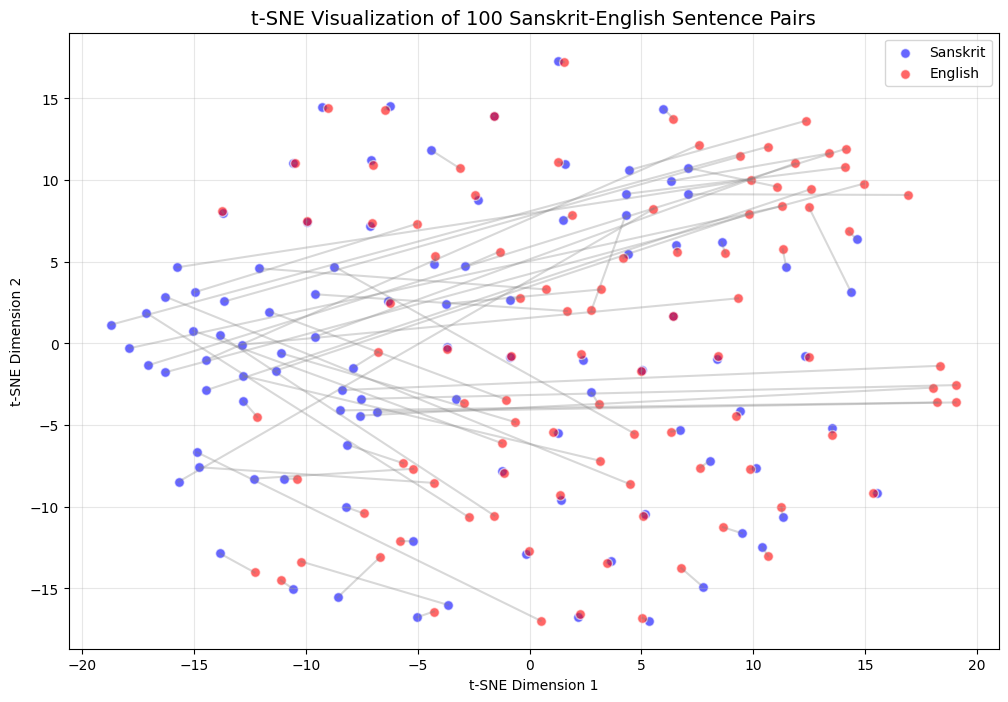

In [ ]:
sample_size = min(100, len(sa_embeddings_reduced))
sa_sample = sa_embeddings_reduced[:sample_size]
en_sample = en_embeddings_reduced[:sample_size]

viz_data = np.vstack((sa_sample, en_sample))
tsne = TSNE(n_components=2, perplexity=30, random_state=42)
tsne_results = tsne.fit_transform(viz_data)

sa_tsne = tsne_results[:sample_size]
en_tsne = tsne_results[sample_size:]

plt.figure(figsize=(12, 8))
plt.scatter(sa_tsne[:, 0], sa_tsne[:, 1], c='blue', label='Sanskrit', alpha=0.6, edgecolors='w', s=50)
plt.scatter(en_tsne[:, 0], en_tsne[:, 1], c='red', label='English', alpha=0.6, edgecolors='w', s=50)

for i in range(sample_size):
    plt.plot([sa_tsne[i, 0], en_tsne[i, 0]], [sa_tsne[i, 1], en_tsne[i, 1]], 'gray', alpha=0.3)

plt.title('t-SNE Visualization of 100 Sanskrit-English Sentence Pairs', fontsize=14)
plt.xlabel('t-SNE Dimension 1')
plt.ylabel('t-SNE Dimension 2')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

In [ ]:
import random

def generate_report_analysis(sa_texts, en_texts, sa_embeddings, en_embeddings, num_examples=5):
    print(f"--- Generating {num_examples} Examples for Report Analysis ---\n")

    total_samples = len(sa_texts)
    random_indices = random.sample(range(total_samples), min(num_examples, total_samples))

    for idx, i in enumerate(random_indices, 1):
        sa_text = sa_texts[i]
        en_text = en_texts[i]

        vec_sa = sa_embeddings[i]
        vec_en = en_embeddings[i]

        sim_score = cosine_similarity(vec_sa.reshape(1, -1), vec_en.reshape(1, -1))[0][0]

        print(f"Example {idx} (Row ID: {i})")
        print(f"Sanskrit: {sa_text}")
        print(f"English:  {en_text}")
        print(f"Cosine Similarity: {sim_score:.4f}")
        print("-" * 50)

generate_report_analysis(
    sa_sentences,
    en_sentences,
    sa_embeddings_reduced,
    en_embeddings_reduced,
    num_examples=10
)

--- Generating 10 Examples for Report Analysis ---

Example 1 (Row ID: 993)
Sanskrit: अपि च वयं ,  अस्माकमेव संस्थां वा कम्पनी वा रचयितुं,
English:  Also, we have learnt how to: Create our own organisation or Company
Cosine Similarity: 0.3806
--------------------------------------------------
Example 2 (Row ID: 6931)
Sanskrit: यूयं परस्परं मृषाकथां न वदत यतो यूयं स्वकर्म्मसहितं पुरातनपुरुषं त्यक्तवन्तः
English:  "Lie not one to another, seeing that ye have put off the old man with his deeds;"
Cosine Similarity: 0.4424
--------------------------------------------------
Example 3 (Row ID: 2018)
Sanskrit: पश्यन्तु, वयमधुना music सन्धारिकायां स्मः।
English:  See, we are in the music directory now.
Cosine Similarity: 0.2977
--------------------------------------------------
Example 4 (Row ID: 9279)
Sanskrit: इदानीं गुणाकारं प्रयतिष्यामः, “मैनस्” चिह्नं “आस्टरिक्” प्रति परिवर्तयन्तु ।
English:  Now Let us try  multiplication. Change minus to asterisk (*).
Cosine Similarity: 0.3324
----------